# Mumbai Data - Temporal Analysis

Visualize when data was collected.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path
from datetime import datetime

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
BASE_DIR = Path('../..')

VIDEO_METADATA_FILES = [
    BASE_DIR / '1_8_exif_video_metadata.csv',
    BASE_DIR / '9_11_exif_video_metadata.csv',
    BASE_DIR / '13_19_6_7_exif_video_metadata.csv',
]

ANNOTATIONS_FILE = BASE_DIR / 'data/mumbai_annotations_with_exif.csv'

## 1. Load Video Metadata

In [3]:
video_dfs = []
for f in VIDEO_METADATA_FILES:
    if f.exists():
        df = pd.read_csv(f)
        df['source_file'] = f.stem
        video_dfs.append(df)
        print(f"{f.name}: {len(df)} videos")

videos = pd.concat(video_dfs, ignore_index=True)
print(f"\nTotal videos: {len(videos)}")

1_8_exif_video_metadata.csv: 85 videos
9_11_exif_video_metadata.csv: 40 videos
13_19_6_7_exif_video_metadata.csv: 49 videos

Total videos: 174


In [4]:
videos['recording_datetime'] = pd.to_datetime(
    videos['recording_datetime'], 
    format='%Y:%m:%d %H:%M:%S', 
    errors='coerce'
)

videos['recording_date'] = videos['recording_datetime'].dt.date
videos['recording_hour'] = videos['recording_datetime'].dt.hour
videos['recording_dayofweek'] = videos['recording_datetime'].dt.dayofweek
videos['recording_day_name'] = videos['recording_datetime'].dt.day_name()

videos['end_datetime'] = videos['recording_datetime'] + pd.to_timedelta(videos['video_duration_sec'], unit='s')

print(f"Valid datetime records: {videos['recording_datetime'].notna().sum()}")
print(f"Date range: {videos['recording_datetime'].min()} to {videos['recording_datetime'].max()}")

Valid datetime records: 174
Date range: 2025-03-20 09:55:11 to 2025-05-15 05:42:47


## 2. Collection Timeline (Gantt Chart)

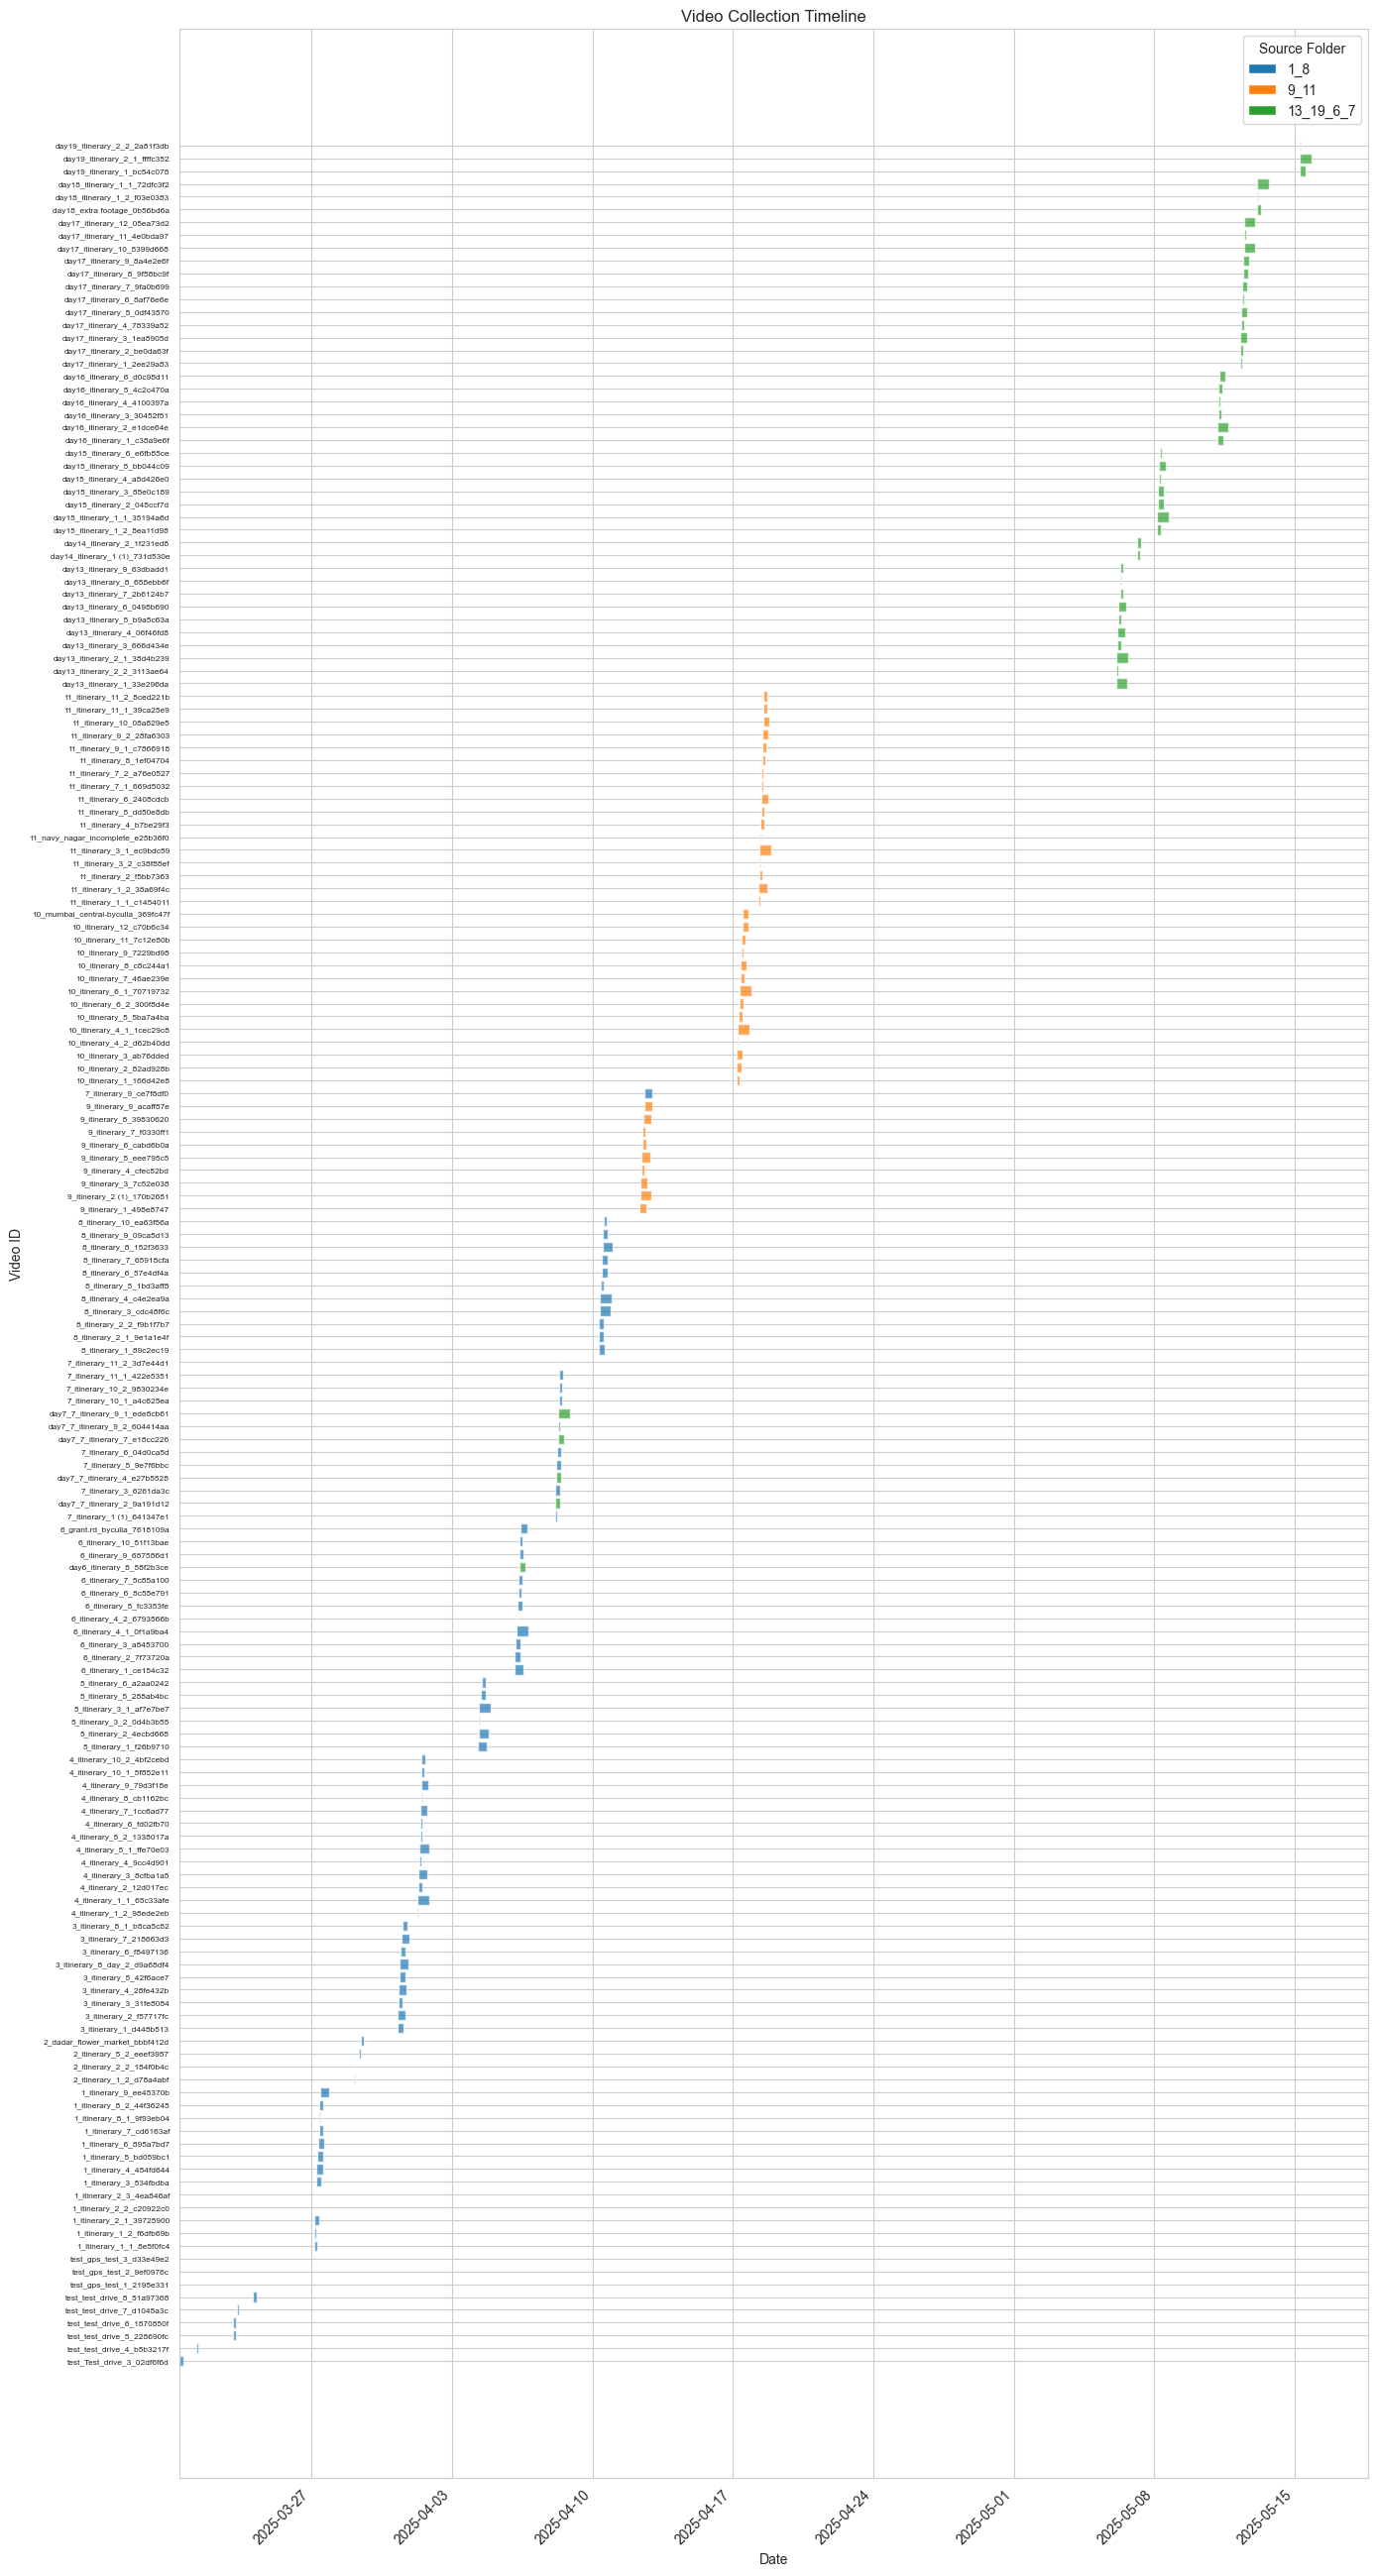

In [5]:
videos_sorted = videos.sort_values('recording_datetime').reset_index(drop=True)
videos_sorted = videos_sorted[videos_sorted['recording_datetime'].notna()]

fig, ax = plt.subplots(figsize=(14, max(8, len(videos_sorted) * 0.15)))

source_colors = {
    '1_8_exif_video_metadata': '#1f77b4',
    '9_11_exif_video_metadata': '#ff7f0e',
    '13_19_6_7_exif_video_metadata': '#2ca02c'
}

for idx, row in videos_sorted.iterrows():
    start = row['recording_datetime']
    duration = row['video_duration_sec'] / 3600
    color = source_colors.get(row['source_file'], 'gray')
    
    ax.barh(idx, duration, left=mdates.date2num(start), height=0.8, color=color, alpha=0.7)

ax.set_yticks(range(len(videos_sorted)))
ax.set_yticklabels(videos_sorted['video_id'], fontsize=6)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=7))
plt.xticks(rotation=45, ha='right')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=k.replace('_exif_video_metadata', '')) 
                   for k, c in source_colors.items()]
ax.legend(handles=legend_elements, loc='upper right', title='Source Folder')

ax.set_xlabel('Date')
ax.set_ylabel('Video ID')
ax.set_title('Video Collection Timeline')

plt.tight_layout()
plt.show()

## 3. Videos Per Day

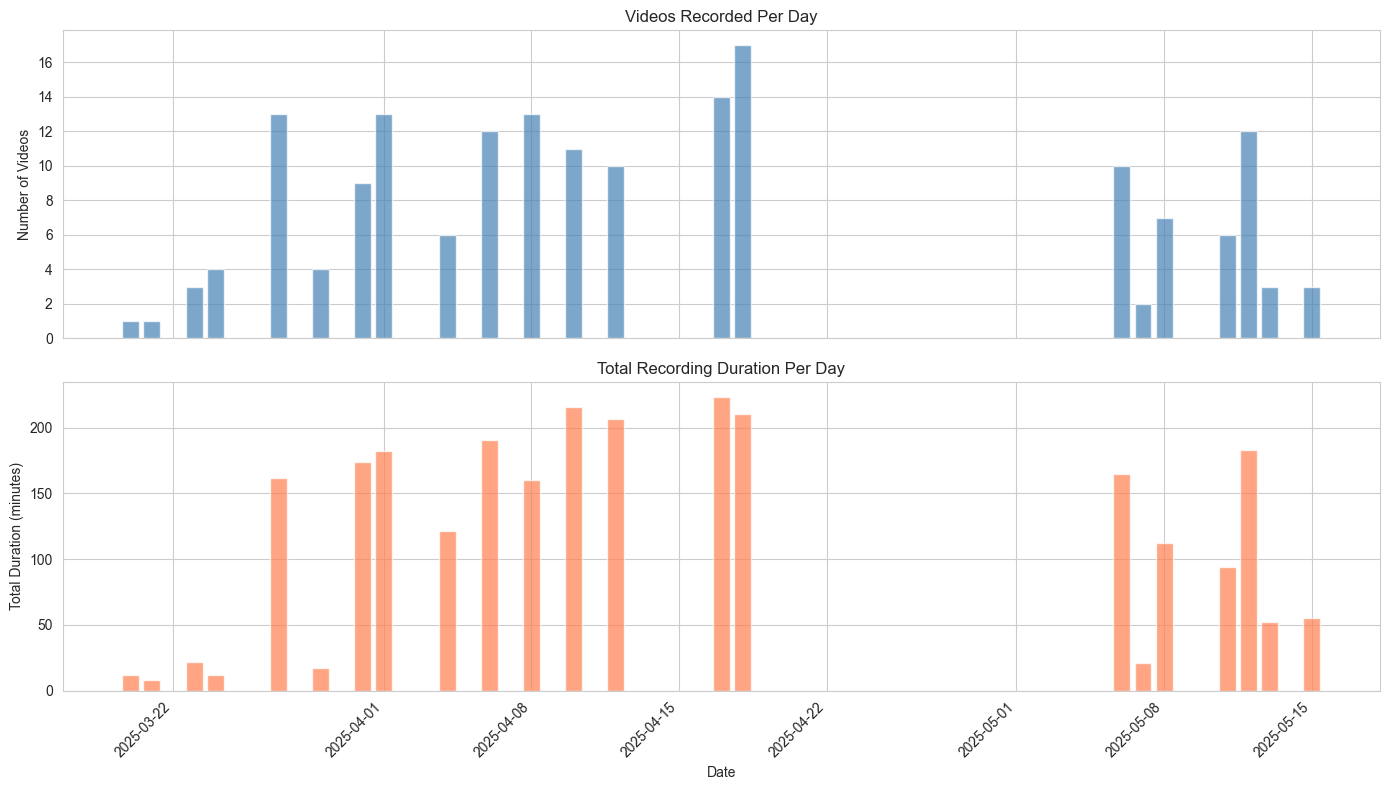


Daily Statistics:
                num_videos  total_duration_sec  total_duration_min
recording_date                                                    
2025-03-20               1               714.0           11.900000
2025-03-21               1               466.0            7.766667
2025-03-23               3              1285.0           21.416667
2025-03-24               4               720.0           12.000000
2025-03-27              13              9696.0          161.600000
2025-03-29               4              1036.0           17.266667
2025-03-31               9             10432.0          173.866667
2025-04-01              13             10949.0          182.483333
2025-04-04               6              7294.0          121.566667
2025-04-06              12             11458.0          190.966667
2025-04-08              13              9628.0          160.466667
2025-04-10              11             12953.0          215.883333
2025-04-12              10             1241

In [6]:
daily_counts = videos.groupby('recording_date').agg({
    'video_id': 'count',
    'video_duration_sec': 'sum'
}).rename(columns={'video_id': 'num_videos', 'video_duration_sec': 'total_duration_sec'})
daily_counts['total_duration_min'] = daily_counts['total_duration_sec'] / 60

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].bar(daily_counts.index, daily_counts['num_videos'], color='steelblue', alpha=0.7)
axes[0].set_ylabel('Number of Videos')
axes[0].set_title('Videos Recorded Per Day')

axes[1].bar(daily_counts.index, daily_counts['total_duration_min'], color='coral', alpha=0.7)
axes[1].set_ylabel('Total Duration (minutes)')
axes[1].set_xlabel('Date')
axes[1].set_title('Total Recording Duration Per Day')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f"\nDaily Statistics:")
print(daily_counts.sort_index())

## 4. Time of Day Distribution

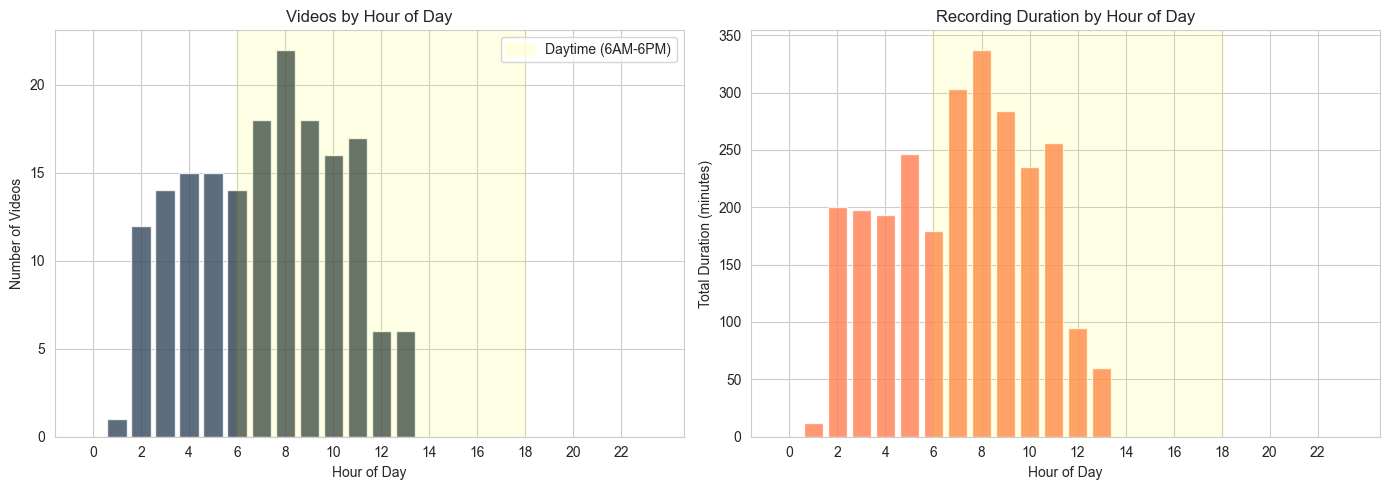


Peak recording hours:
recording_hour
8     22
7     18
9     18
11    17
10    16
Name: count, dtype: int64


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

hourly_counts = videos['recording_hour'].value_counts().sort_index()
all_hours = pd.Series(0, index=range(24))
all_hours.update(hourly_counts)

colors = ['#2c3e50' if 6 <= h < 18 else '#34495e' for h in range(24)]
axes[0].bar(all_hours.index, all_hours.values, color=colors, alpha=0.8)
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Number of Videos')
axes[0].set_title('Videos by Hour of Day')
axes[0].set_xticks(range(0, 24, 2))
axes[0].axvspan(6, 18, alpha=0.1, color='yellow', label='Daytime (6AM-6PM)')
axes[0].legend()

hourly_duration = videos.groupby('recording_hour')['video_duration_sec'].sum() / 60
all_hours_dur = pd.Series(0.0, index=range(24))
all_hours_dur.update(hourly_duration)

axes[1].bar(all_hours_dur.index, all_hours_dur.values, color='coral', alpha=0.8)
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Total Duration (minutes)')
axes[1].set_title('Recording Duration by Hour of Day')
axes[1].set_xticks(range(0, 24, 2))
axes[1].axvspan(6, 18, alpha=0.1, color='yellow')

plt.tight_layout()
plt.show()

print(f"\nPeak recording hours:")
print(hourly_counts.nlargest(5))

## 5. Day of Week Distribution

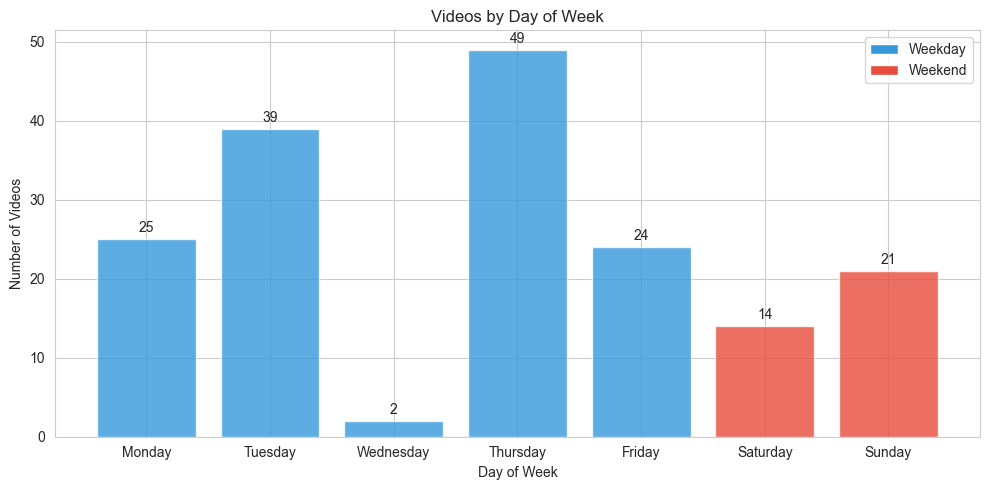

In [8]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_counts = videos['recording_day_name'].value_counts().reindex(day_order).fillna(0)

fig, ax = plt.subplots(figsize=(10, 5))

colors = ['#e74c3c' if d in ['Saturday', 'Sunday'] else '#3498db' for d in day_order]
bars = ax.bar(dow_counts.index, dow_counts.values, color=colors, alpha=0.8)

ax.set_xlabel('Day of Week')
ax.set_ylabel('Number of Videos')
ax.set_title('Videos by Day of Week')

for bar, count in zip(bars, dow_counts.values):
    if count > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
                f'{int(count)}', ha='center', va='bottom')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#3498db', label='Weekday'),
    Patch(facecolor='#e74c3c', label='Weekend')
]
ax.legend(handles=legend_elements)

plt.tight_layout()
plt.show()

## 6. Collection by Source Folder

In [9]:
source_stats = videos.groupby('source_folder').agg({
    'video_id': 'count',
    'video_duration_sec': ['sum', 'mean'],
    'recording_datetime': ['min', 'max']
}).round(1)

source_stats.columns = ['num_videos', 'total_duration_sec', 'avg_duration_sec', 'first_recording', 'last_recording']
source_stats['total_duration_min'] = (source_stats['total_duration_sec'] / 60).round(1)
source_stats['avg_duration_min'] = (source_stats['avg_duration_sec'] / 60).round(1)

print("Collection Statistics by Source Folder:")
print(source_stats[['num_videos', 'total_duration_min', 'avg_duration_min', 'first_recording', 'last_recording']])

Collection Statistics by Source Folder:
               num_videos  total_duration_min  avg_duration_min  \
source_folder                                                     
9                       9               182.6              20.3   
10                     14               223.4              16.0   
11                     17               210.8              12.4   
1                      13               161.6              13.5   
2                       4                17.3               4.3   
3                       9               173.9              19.3   
4                      13               182.5              14.0   
5                       6               121.6              20.3   
6                      11               171.6              15.6   
7                       9                97.0              10.8   
8                      11               215.9              19.6   
day13                  10               165.1              16.5   
day14                 

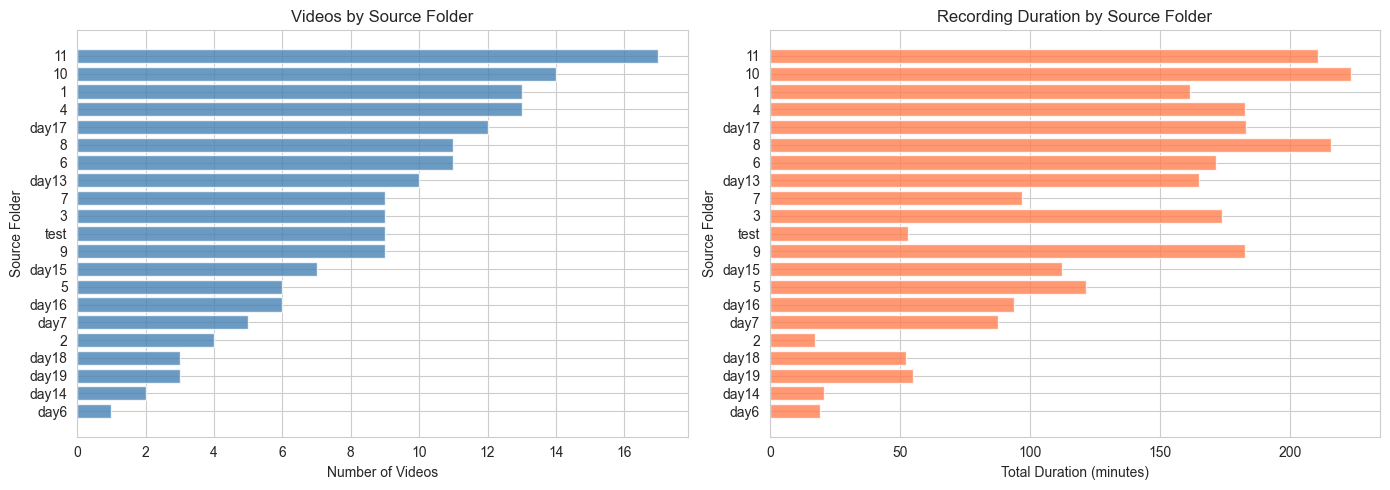

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

source_stats_sorted = source_stats.sort_values('num_videos', ascending=True)

axes[0].barh(source_stats_sorted.index.astype(str), source_stats_sorted['num_videos'], color='steelblue', alpha=0.8)
axes[0].set_xlabel('Number of Videos')
axes[0].set_ylabel('Source Folder')
axes[0].set_title('Videos by Source Folder')

axes[1].barh(source_stats_sorted.index.astype(str), source_stats_sorted['total_duration_min'], color='coral', alpha=0.8)
axes[1].set_xlabel('Total Duration (minutes)')
axes[1].set_ylabel('Source Folder')
axes[1].set_title('Recording Duration by Source Folder')

plt.tight_layout()
plt.show()

## 7. Video Duration Distribution

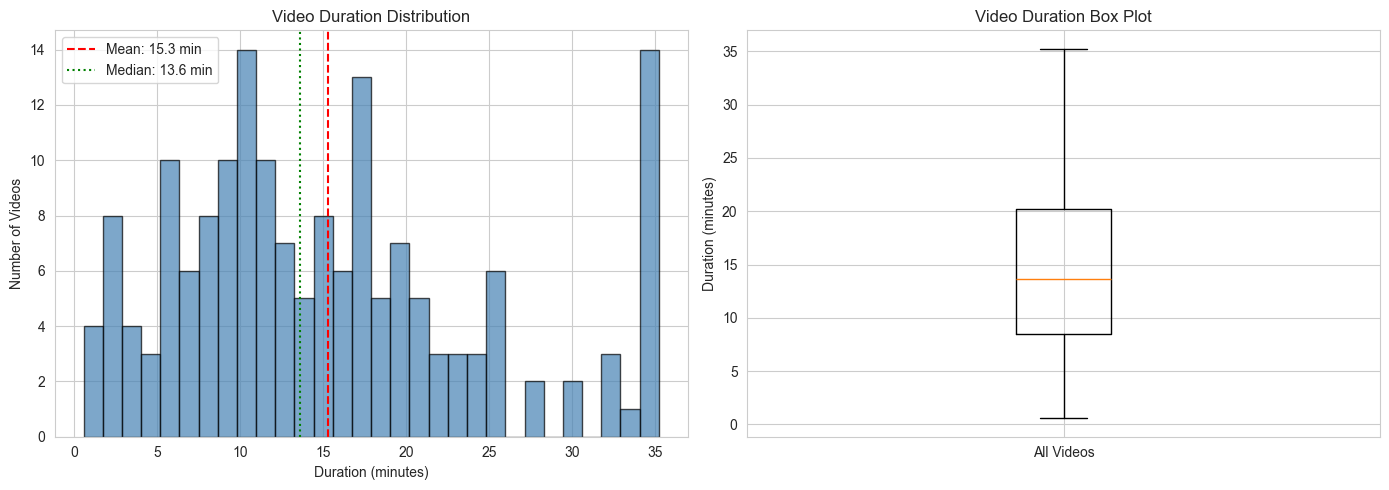


Duration Statistics:
  Min: 0.6 min
  Max: 35.2 min
  Mean: 15.3 min
  Median: 13.6 min
  Total: 2600.9 min (43.3 hours)


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

duration_min = videos['video_duration_sec'] / 60

axes[0].hist(duration_min.dropna(), bins=30, color='steelblue', alpha=0.7, edgecolor='black')
axes[0].axvline(duration_min.mean(), color='red', linestyle='--', label=f'Mean: {duration_min.mean():.1f} min')
axes[0].axvline(duration_min.median(), color='green', linestyle=':', label=f'Median: {duration_min.median():.1f} min')
axes[0].set_xlabel('Duration (minutes)')
axes[0].set_ylabel('Number of Videos')
axes[0].set_title('Video Duration Distribution')
axes[0].legend()

axes[1].boxplot([duration_min.dropna()], vert=True)
axes[1].set_ylabel('Duration (minutes)')
axes[1].set_title('Video Duration Box Plot')
axes[1].set_xticklabels(['All Videos'])

plt.tight_layout()
plt.show()

print(f"\nDuration Statistics:")
print(f"  Min: {duration_min.min():.1f} min")
print(f"  Max: {duration_min.max():.1f} min")
print(f"  Mean: {duration_min.mean():.1f} min")
print(f"  Median: {duration_min.median():.1f} min")
print(f"  Total: {duration_min.sum():.1f} min ({duration_min.sum()/60:.1f} hours)")

## 8. Summary

In [12]:
print("=" * 50)
print("TEMPORAL ANALYSIS SUMMARY")
print("=" * 50)

print(f"\nCollection Period:")
print(f"  First recording: {videos['recording_datetime'].min()}")
print(f"  Last recording: {videos['recording_datetime'].max()}")
num_days = (videos['recording_datetime'].max() - videos['recording_datetime'].min()).days + 1
print(f"  Span: {num_days} days")

print(f"\nCollection Volume:")
print(f"  Total videos: {len(videos)}")
print(f"  Total duration: {videos['video_duration_sec'].sum()/3600:.1f} hours")
print(f"  Unique days: {videos['recording_date'].nunique()}")

print(f"\nPeak Times:")
peak_hour = videos['recording_hour'].mode().iloc[0] if len(videos['recording_hour'].mode()) > 0 else 'N/A'
peak_day = videos['recording_day_name'].mode().iloc[0] if len(videos['recording_day_name'].mode()) > 0 else 'N/A'
print(f"  Most common hour: {peak_hour}:00")
print(f"  Most common day: {peak_day}")

TEMPORAL ANALYSIS SUMMARY

Collection Period:
  First recording: 2025-03-20 09:55:11
  Last recording: 2025-05-15 05:42:47
  Span: 56 days

Collection Volume:
  Total videos: 174
  Total duration: 43.3 hours
  Unique days: 22

Peak Times:
  Most common hour: 8:00
  Most common day: Thursday


## 9. Men/Women Distribution by Time of Day

Analysis of how men and women counts vary by hour of day based on annotated frames.

In [13]:
annotations = pd.read_csv(ANNOTATIONS_FILE)
annotations['frame_datetime'] = pd.to_datetime(annotations['frame_datetime'])

print(f"Loaded {len(annotations)} annotations")
print(f"With men_count: {annotations['men_count'].notna().sum()}")
print(f"With women_count: {annotations['women_count'].notna().sum()}")
print(f"With frame_hour: {annotations['frame_hour'].notna().sum()}")

Loaded 2744 annotations
With men_count: 2180
With women_count: 1157
With frame_hour: 2744


In [14]:
hourly_gender = annotations.groupby('frame_hour').agg({
    'men_count': ['mean', 'sum', 'count'],
    'women_count': ['mean', 'sum', 'count']
}).round(2)

hourly_gender.columns = ['men_mean', 'men_total', 'men_n', 'women_mean', 'women_total', 'women_n']

hourly_gender['total_mean'] = hourly_gender['men_mean'] + hourly_gender['women_mean']
hourly_gender['women_proportion'] = hourly_gender['women_mean'] / hourly_gender['total_mean']

print("Hourly Gender Statistics:")
print(hourly_gender)

Hourly Gender Statistics:
            men_mean  men_total  men_n  women_mean  women_total  women_n  \
frame_hour                                                                 
1               4.20       21.0      5        1.75          7.0        4   
2               3.40      119.0     35        2.15         28.0       13   
3               4.88      654.0    134        1.97        128.0       65   
4               4.10      587.0    143        1.88        145.0       77   
5               4.90     1714.0    350        2.09        470.0      225   
6               4.23      478.0    113        2.64        206.0       78   
7               4.63     1157.0    250        2.25        306.0      136   
8               4.62     1281.0    277        1.99        261.0      131   
9               3.91      832.0    213        1.81        196.0      108   
10              4.39      992.0    226        2.01        213.0      106   
11              4.87     1296.0    266        2.04        269.

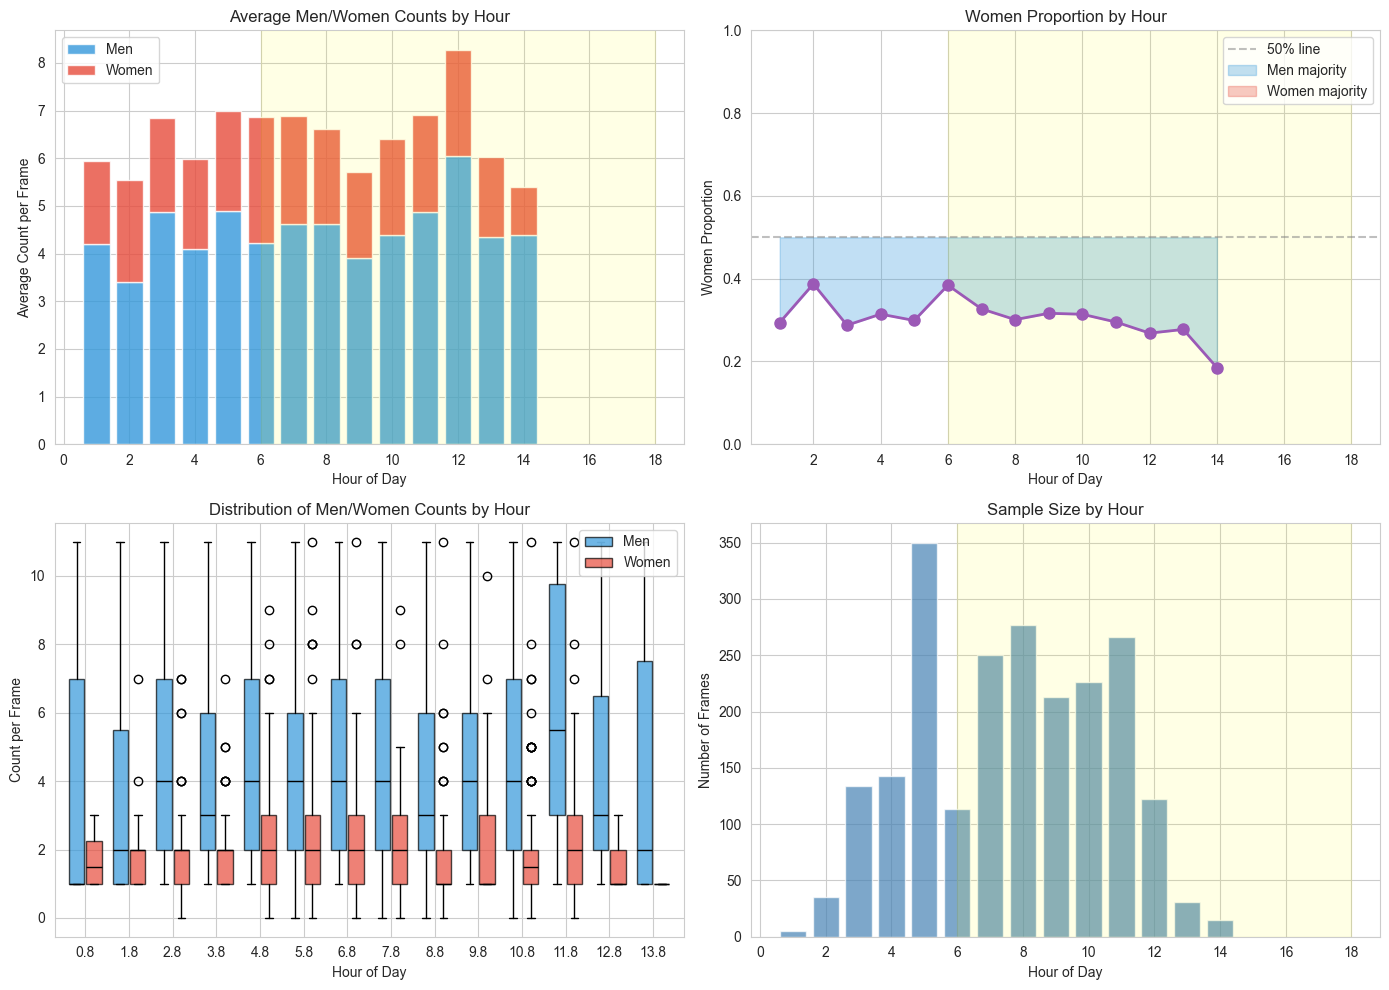

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax1 = axes[0, 0]
hours = hourly_gender.index
width = 0.8
ax1.bar(hours, hourly_gender['men_mean'], width, label='Men', color='#3498db', alpha=0.8)
ax1.bar(hours, hourly_gender['women_mean'], width, bottom=hourly_gender['men_mean'], 
        label='Women', color='#e74c3c', alpha=0.8)
ax1.set_xlabel('Hour of Day')
ax1.set_ylabel('Average Count per Frame')
ax1.set_title('Average Men/Women Counts by Hour')
ax1.set_xticks(range(0, 24, 2))
ax1.legend()
ax1.axvspan(6, 18, alpha=0.1, color='yellow')

ax2 = axes[0, 1]
valid_proportion = hourly_gender['women_proportion'].dropna()
ax2.plot(valid_proportion.index, valid_proportion.values, 'o-', color='#9b59b6', linewidth=2, markersize=8)
ax2.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='50% line')
ax2.fill_between(valid_proportion.index, valid_proportion.values, 0.5, 
                  where=(valid_proportion.values < 0.5), alpha=0.3, color='#3498db', label='Men majority')
ax2.fill_between(valid_proportion.index, valid_proportion.values, 0.5,
                  where=(valid_proportion.values >= 0.5), alpha=0.3, color='#e74c3c', label='Women majority')
ax2.set_xlabel('Hour of Day')
ax2.set_ylabel('Women Proportion')
ax2.set_title('Women Proportion by Hour')
ax2.set_xticks(range(0, 24, 2))
ax2.set_ylim(0, 1)
ax2.legend(loc='upper right')
ax2.axvspan(6, 18, alpha=0.1, color='yellow')

ax3 = axes[1, 0]
men_by_hour = [annotations[annotations['frame_hour'] == h]['men_count'].dropna().values for h in range(24)]
women_by_hour = [annotations[annotations['frame_hour'] == h]['women_count'].dropna().values for h in range(24)]

hours_with_data = [h for h in range(24) if len(men_by_hour[h]) > 0]
men_data = [men_by_hour[h] for h in hours_with_data]
women_data = [women_by_hour[h] for h in hours_with_data]

positions_men = [h - 0.2 for h in hours_with_data]
positions_women = [h + 0.2 for h in hours_with_data]

bp1 = ax3.boxplot(men_data, positions=positions_men, widths=0.35, patch_artist=True,
                   boxprops=dict(facecolor='#3498db', alpha=0.7),
                   medianprops=dict(color='black'))
bp2 = ax3.boxplot(women_data, positions=positions_women, widths=0.35, patch_artist=True,
                   boxprops=dict(facecolor='#e74c3c', alpha=0.7),
                   medianprops=dict(color='black'))
ax3.set_xlabel('Hour of Day')
ax3.set_ylabel('Count per Frame')
ax3.set_title('Distribution of Men/Women Counts by Hour')
ax3.set_xticks(hours_with_data)
ax3.legend([bp1['boxes'][0], bp2['boxes'][0]], ['Men', 'Women'], loc='upper right')

ax4 = axes[1, 1]
ax4.bar(hours, hourly_gender['men_n'], color='steelblue', alpha=0.7)
ax4.set_xlabel('Hour of Day')
ax4.set_ylabel('Number of Frames')
ax4.set_title('Sample Size by Hour')
ax4.set_xticks(range(0, 24, 2))
ax4.axvspan(6, 18, alpha=0.1, color='yellow')

plt.tight_layout()
plt.show()

### Two-Wheeler Analysis by Time of Day

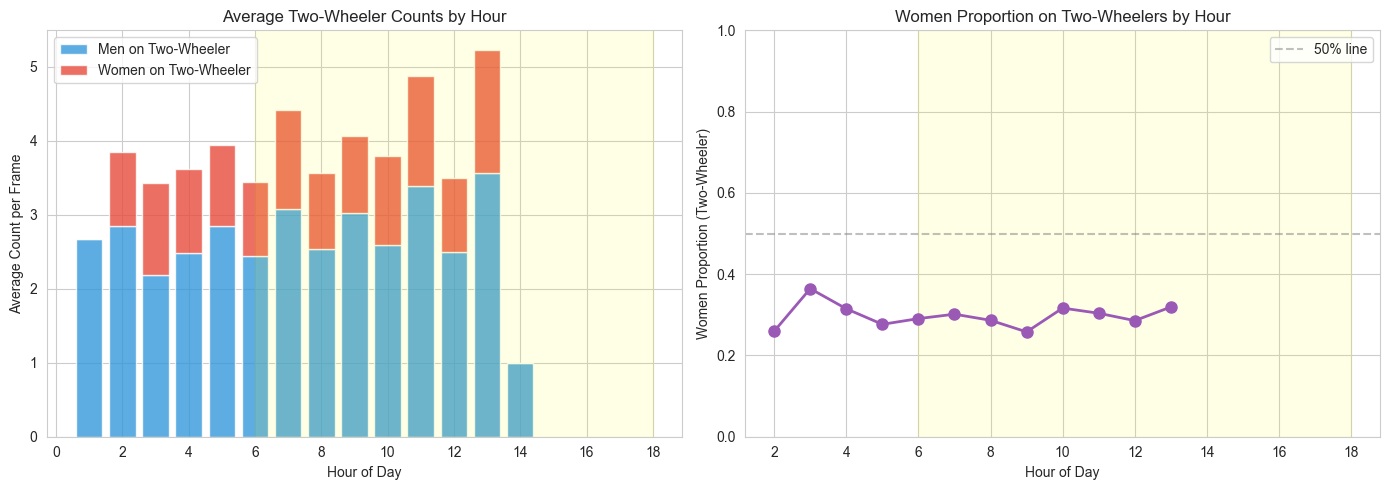


Two-Wheeler Hourly Statistics:
            men_tw_mean  women_tw_mean  women_tw_proportion
frame_hour                                                 
1                  2.67            NaN                  NaN
2                  2.85           1.00             0.259740
3                  2.18           1.25             0.364431
4                  2.48           1.14             0.314917
5                  2.85           1.09             0.276650
6                  2.44           1.00             0.290698
7                  3.08           1.33             0.301587
8                  2.54           1.02             0.286517
9                  3.02           1.05             0.257985
10                 2.59           1.20             0.316623
11                 3.39           1.48             0.303901
12                 2.50           1.00             0.285714
13                 3.56           1.67             0.319312
14                 1.00            NaN                  NaN


In [16]:
hourly_twowheeler = annotations.groupby('frame_hour').agg({
    'men_twowheeler': ['mean', 'sum', 'count'],
    'women_twowheeler': ['mean', 'sum', 'count']
}).round(2)

hourly_twowheeler.columns = ['men_tw_mean', 'men_tw_total', 'men_tw_n', 
                              'women_tw_mean', 'women_tw_total', 'women_tw_n']

hourly_twowheeler['total_tw_mean'] = hourly_twowheeler['men_tw_mean'].fillna(0) + hourly_twowheeler['women_tw_mean'].fillna(0)
hourly_twowheeler['women_tw_proportion'] = hourly_twowheeler['women_tw_mean'] / hourly_twowheeler['total_tw_mean']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
hours = hourly_twowheeler.index
ax1.bar(hours, hourly_twowheeler['men_tw_mean'].fillna(0), width, label='Men on Two-Wheeler', color='#3498db', alpha=0.8)
ax1.bar(hours, hourly_twowheeler['women_tw_mean'].fillna(0), width, 
        bottom=hourly_twowheeler['men_tw_mean'].fillna(0), label='Women on Two-Wheeler', color='#e74c3c', alpha=0.8)
ax1.set_xlabel('Hour of Day')
ax1.set_ylabel('Average Count per Frame')
ax1.set_title('Average Two-Wheeler Counts by Hour')
ax1.set_xticks(range(0, 24, 2))
ax1.legend()
ax1.axvspan(6, 18, alpha=0.1, color='yellow')

ax2 = axes[1]
valid_tw_proportion = hourly_twowheeler['women_tw_proportion'].dropna()
ax2.plot(valid_tw_proportion.index, valid_tw_proportion.values, 'o-', color='#9b59b6', linewidth=2, markersize=8)
ax2.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='50% line')
ax2.set_xlabel('Hour of Day')
ax2.set_ylabel('Women Proportion (Two-Wheeler)')
ax2.set_title('Women Proportion on Two-Wheelers by Hour')
ax2.set_xticks(range(0, 24, 2))
ax2.set_ylim(0, 1)
ax2.legend(loc='upper right')
ax2.axvspan(6, 18, alpha=0.1, color='yellow')

plt.tight_layout()
plt.show()

print("\nTwo-Wheeler Hourly Statistics:")
print(hourly_twowheeler[['men_tw_mean', 'women_tw_mean', 'women_tw_proportion']])

### Gender Ratio Summary

In [17]:
print("=" * 50)
print("GENDER BY TIME OF DAY SUMMARY")
print("=" * 50)

overall_men = annotations['men_count'].sum()
overall_women = annotations['women_count'].sum()
overall_proportion = overall_women / (overall_men + overall_women) if (overall_men + overall_women) > 0 else 0

print(f"\nOverall Counts:")
print(f"  Total men observed: {overall_men:.0f}")
print(f"  Total women observed: {overall_women:.0f}")
print(f"  Women proportion: {overall_proportion:.1%}")

print(f"\nHourly Variation:")
if len(valid_proportion) > 0:
    min_hour = valid_proportion.idxmin()
    max_hour = valid_proportion.idxmax()
    print(f"  Lowest women proportion: {valid_proportion.min():.1%} at {min_hour}:00")
    print(f"  Highest women proportion: {valid_proportion.max():.1%} at {max_hour}:00")

print(f"\nTwo-Wheeler Stats:")
overall_men_tw = annotations['men_twowheeler'].sum()
overall_women_tw = annotations['women_twowheeler'].sum()
if (overall_men_tw + overall_women_tw) > 0:
    tw_proportion = overall_women_tw / (overall_men_tw + overall_women_tw)
    print(f"  Total men on two-wheelers: {overall_men_tw:.0f}")
    print(f"  Total women on two-wheelers: {overall_women_tw:.0f}")
    print(f"  Women proportion (two-wheeler): {tw_proportion:.1%}")

GENDER BY TIME OF DAY SUMMARY

Overall Counts:
  Total men observed: 10070
  Total women observed: 2405
  Women proportion: 19.3%

Hourly Variation:
  Lowest women proportion: 18.5% at 14:00
  Highest women proportion: 38.7% at 2:00

Two-Wheeler Stats:
  Total men on two-wheelers: 4914
  Total women on two-wheelers: 447
  Women proportion (two-wheeler): 8.3%
